# Exploratory Data Analysis
## Drift-Aware Demand Forecasting — M.Tech Project

**Dataset:** `data/raw/sales_with_sku.csv`  
**Period:** 2024-01-01 → 2025-12-31  
**Scope:** 72 SKUs across 24 product categories

---
**Contents**
1. Load & inspect dataset  
2. Missing-value audit  
3. Sales trend over time  
4. SKU-level demand distribution  
5. Category distribution  
6. Seasonality analysis  
7. Daily demand aggregation preview

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Plot style ────────────────────────────────────────────────────────────────
BG     = "#ffffff"
CARD   = "#f8fafc"
ACCENT = "#2563eb"
GREEN  = "#16a34a"
YELLOW = "#d97706"
RED    = "#dc2626"
TEXT   = "#1e293b"
MUTED  = "#64748b"

plt.rcParams.update({
    "figure.facecolor": BG,       "axes.facecolor":  CARD,
    "axes.edgecolor":   "#cbd5e1","axes.labelcolor": TEXT,
    "axes.titlecolor":  TEXT,     "text.color":      TEXT,
    "xtick.color":      MUTED,    "ytick.color":     MUTED,
    "grid.color":       "#e2e8f0","grid.linewidth":  0.6,
    "figure.dpi":       110,      "font.size":       11,
})

FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load & Inspect Dataset

In [2]:
RAW_PATH = Path("../data/raw/sales_with_sku.csv")

df = pd.read_csv(RAW_PATH)
df["Date_of_Sale"] = pd.to_datetime(df["Date_of_Sale"], format="%Y-%m-%d", errors="coerce")

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range    : {df['Date_of_Sale'].min().date()}  →  {df['Date_of_Sale'].max().date()}")
print(f"Unique SKUs   : {df['SKU'].nunique()}")
print(f"Categories    : {df['Product_Category'].nunique()}")
print(f"Regions       : {df['Sales_Region'].nunique()}")
print()
df.head()

Shape         : 160,000 rows × 11 columns
Date range    : 2024-01-01  →  2025-01-31
Unique SKUs   : 72
Categories    : 24
Regions       : 38107



,Sales_ID,Product_Category,SKU,SKU_Name,Sales_Amount,Discount,Sales_Region,Date_of_Sale,Customer_Age,Customer_Gender,Sales_Representative
0,efc35a5f-e48c-4803-9f6d-ef32a60e1367,Movies,MOVI-001,Action DVD Pack,341.05,45.98,East Dianeport,2024-07-12,69.0,Male,Bruce Rodriguez
1,92a86e42-de42-4e0d-89f3-bbb0b7f354bd,Pet Supplies,PETS-003,Pet Collar,594.71,29.59,North Linda,2024-05-07,32.0,Other,Patricia Pugh
2,1fbbdc48-f405-48f3-8274-750581552d26,Outdoor,OUTD-002,Sleeping Bag,351.90,49.78,Lake Josephmouth,2024-05-11,28.0,Other,Kevin Fuentes
3,1f329e7a-13f0-4518-9eeb-84815301d64c,Electronics,ELEC-002,USB-C Hub 7-Port,546.47,25.27,North Martinside,2024-09-02,44.0,Other,Evelyn Price
4,6ef559dc-3e68-4009-9845-4bab54d897c6,Books,BOOK-002,Academic Textbook,795.75,27.21,Michealshire,2024-05-02,21.0,Other,Joseph Chavez


## 2. Missing Value Audit

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

audit = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(audit[audit["Missing Count"] > 0].to_string() or "✓ No missing values found.")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\nColumn dtypes:")
print(df.dtypes)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Duplicate rows: 0

Column dtypes:
Sales_ID                        object
Product_Category                object
SKU                             object
SKU_Name                        object
Sales_Amount                   float64
Discount                       float64
Sales_Region                    object
Date_of_Sale            datetime64[ns]
Customer_Age                   float64
Customer_Gender                 object
Sales_Representative            object
dtype: object


## 3. Sales Trend Over Time

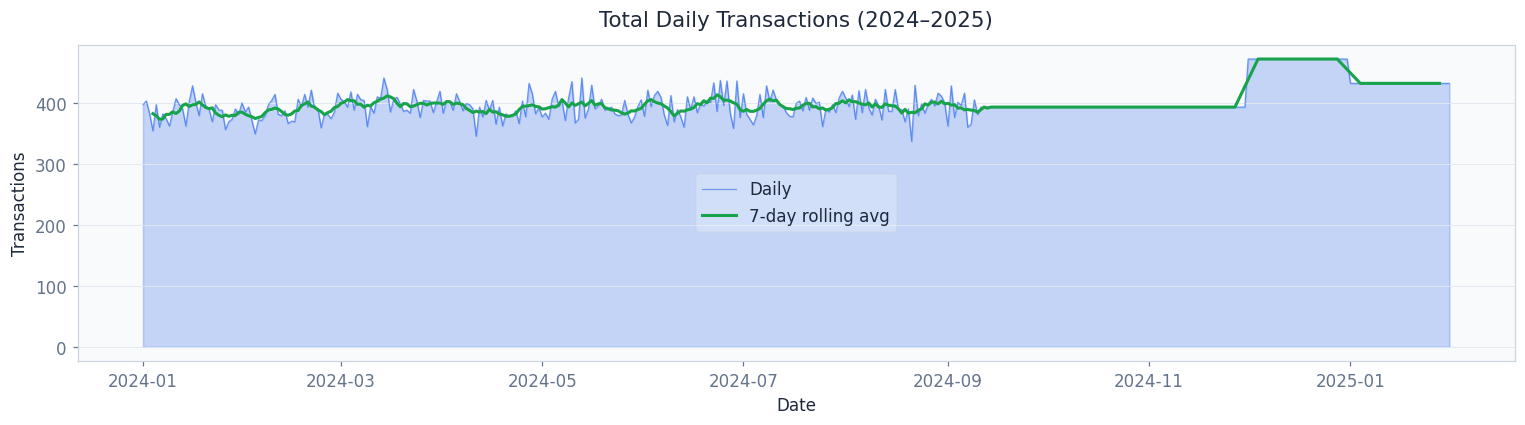

In [4]:
# Aggregate total daily transactions across all SKUs
daily_total = (
    df.groupby("Date_of_Sale")
    .size()
    .reset_index(name="transactions")
)

# 7-day rolling average to smooth noise
daily_total["rolling_7d"] = daily_total["transactions"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily_total["Date_of_Sale"], daily_total["transactions"],
                alpha=0.25, color=ACCENT)
ax.plot(daily_total["Date_of_Sale"], daily_total["transactions"],
        color=ACCENT, lw=0.8, alpha=0.6, label="Daily")
ax.plot(daily_total["Date_of_Sale"], daily_total["rolling_7d"],
        color=GREEN, lw=2, label="7-day rolling avg")

ax.set_title("Total Daily Transactions (2024–2025)", fontsize=14, pad=12)
ax.set_xlabel("Date"); ax.set_ylabel("Transactions")
ax.legend(framealpha=0.3)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIGURES / "sales_trend.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. SKU-Level Demand Distribution

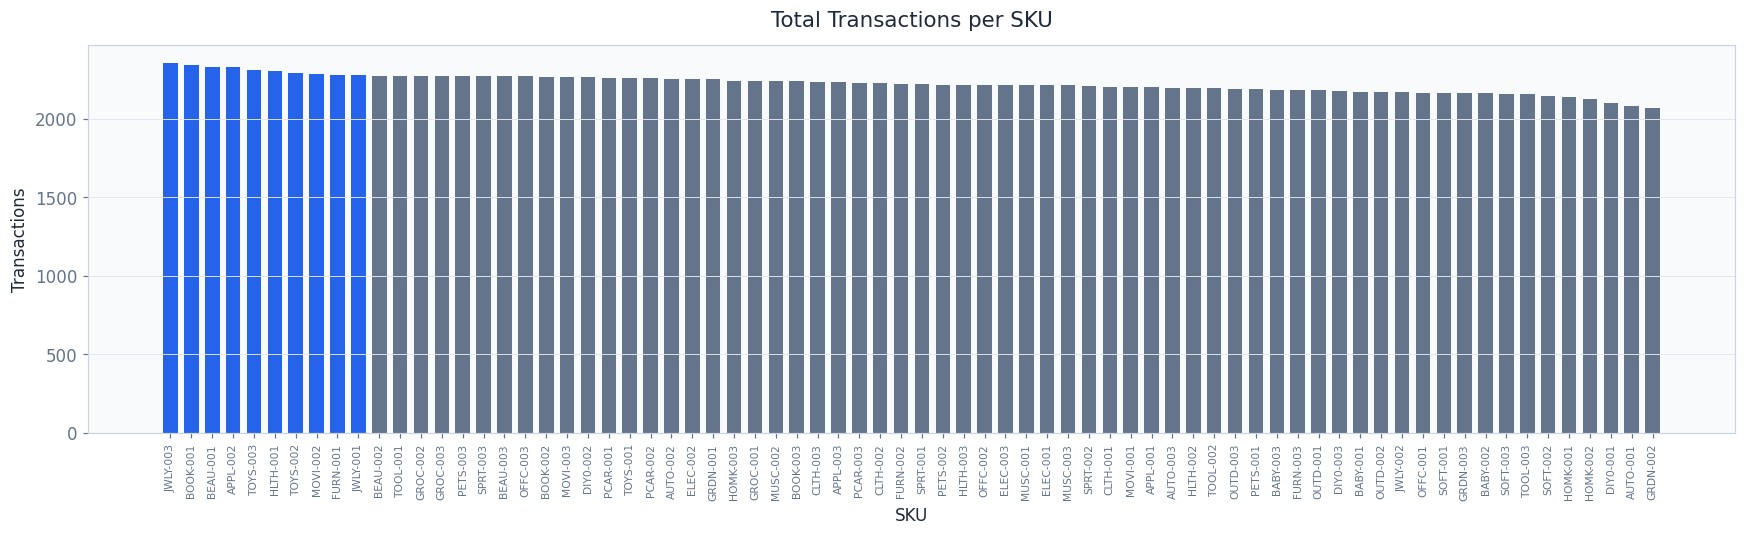

Top 5 SKUs by demand:
SKU
JWLY-003    2353
BOOK-001    2340
BEAU-001    2327
APPL-002    2327
TOYS-003    2306

Bottom 5 SKUs by demand:
SKU
HOMK-001    2137
HOMK-002    2124
DIY0-001    2102
AUTO-001    2081
GRDN-002    2067


In [5]:
sku_demand = df.groupby("SKU").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
colors = [ACCENT if i < 10 else MUTED for i in range(len(sku_demand))]
ax.bar(sku_demand.index, sku_demand.values, color=colors, width=0.7)
ax.set_title("Total Transactions per SKU", fontsize=14, pad=12)
ax.set_xlabel("SKU"); ax.set_ylabel("Transactions")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIGURES / "sku_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Top 5 SKUs by demand:\n{sku_demand.head().to_string()}")
print(f"\nBottom 5 SKUs by demand:\n{sku_demand.tail().to_string()}")

## 5. Category Distribution

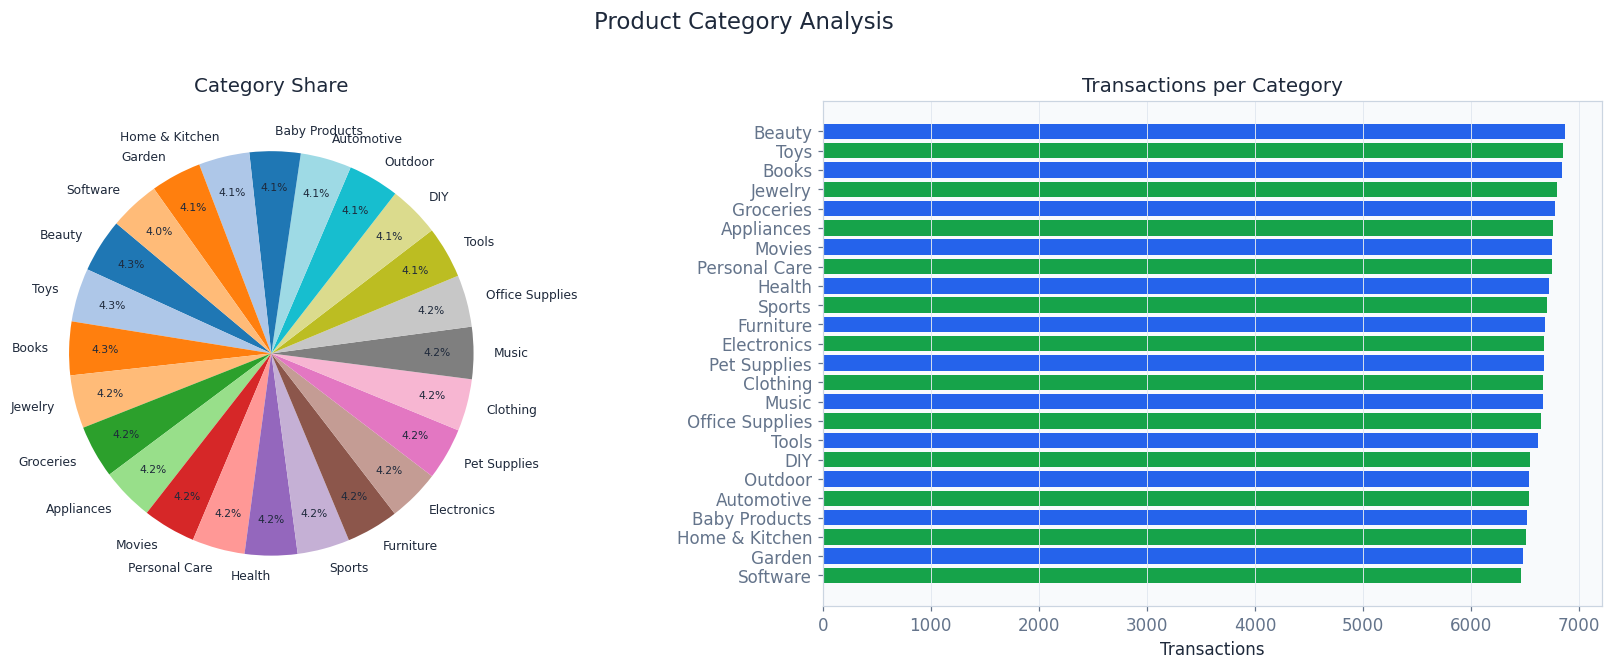

In [6]:
cat_counts = df["Product_Category"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Pie chart ---
wedge_colors = plt.cm.tab20.colors
wedges, texts, autotexts = ax1.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors,
    pctdistance=0.82,
    startangle=140,
)
for t in texts:
    t.set_fontsize(8)
    t.set_color(TEXT)
for at in autotexts:
    at.set_fontsize(7)
    at.set_color(TEXT)
ax1.set_title("Category Share", fontsize=13)

# --- Horizontal bar chart ---
bar_colors = [ACCENT if i % 2 == 0 else GREEN for i in range(len(cat_counts))]
ax2.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=bar_colors[::-1])
ax2.set_title("Transactions per Category", fontsize=13)
ax2.set_xlabel("Transactions")
ax2.grid(True, axis="x")

plt.suptitle("Product Category Analysis", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "category_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Seasonality Analysis — Monthly & Weekly Patterns

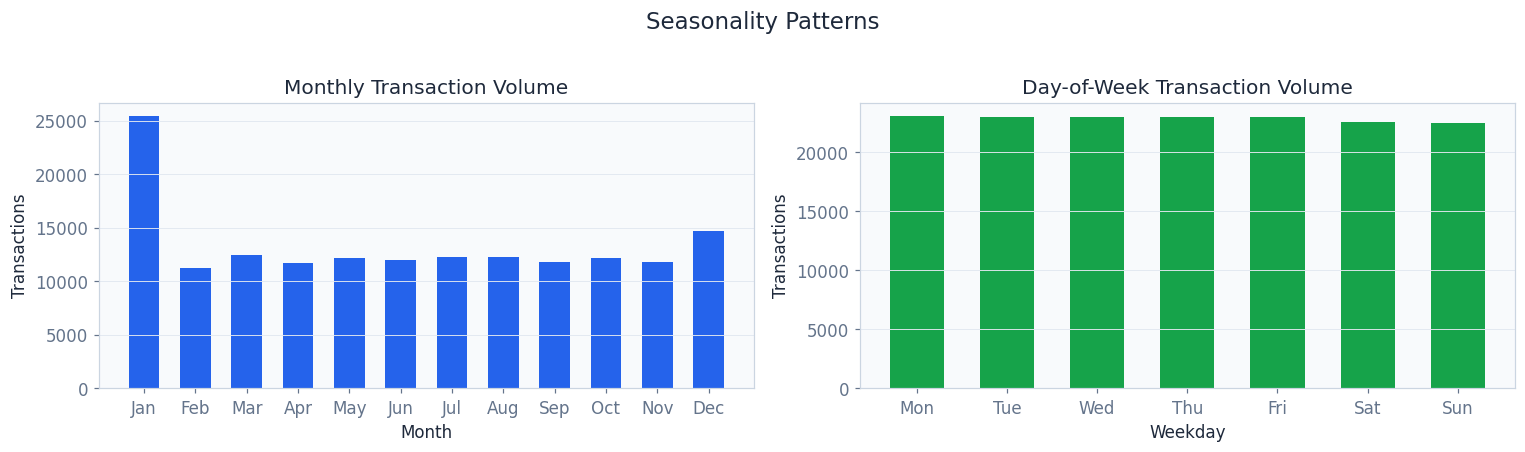

In [7]:
df["month"]    = df["Date_of_Sale"].dt.month
df["dayofweek"] = df["Date_of_Sale"].dt.dayofweek
df["year"]      = df["Date_of_Sale"].dt.year

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DOW_LABELS   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly demand
monthly = df.groupby("month").size()
axes[0].bar(MONTH_LABELS, [monthly.get(m, 0) for m in range(1, 13)],
            color=ACCENT, width=0.6)
axes[0].set_title("Monthly Transaction Volume")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Transactions")
axes[0].grid(True, axis="y")

# Day-of-week demand
dow = df.groupby("dayofweek").size()
axes[1].bar(DOW_LABELS, [dow.get(d, 0) for d in range(7)],
            color=GREEN, width=0.6)
axes[1].set_title("Day-of-Week Transaction Volume")
axes[1].set_xlabel("Weekday"); axes[1].set_ylabel("Transactions")
axes[1].grid(True, axis="y")

plt.suptitle("Seasonality Patterns", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "seasonality.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Daily Demand Aggregation Preview

This is the output format consumed by the Prophet forecasting module.

In [8]:
# Aggregate to daily demand per SKU (same logic as src/data_preprocessing.py)
daily = (
    df.groupby(["Date_of_Sale", "SKU"])
    .agg(demand=("Sales_ID", "count"))
    .reset_index()
    .rename(columns={"Date_of_Sale": "Date"})
)

print(f"Daily demand shape  : {daily.shape}")
print(f"Date range          : {daily['Date'].min().date()} → {daily['Date'].max().date()}")
print(f"SKUs                : {daily['SKU'].nunique()}")
print(f"\nSample (first 10 rows):")
daily.head(10)

Daily demand shape  : (28466, 3)
Date range          : 2024-01-01 → 2025-01-31
SKUs                : 72

Sample (first 10 rows):


,Date,SKU,demand
0,2024-01-01,APPL-001,11
1,2024-01-01,APPL-002,9
2,2024-01-01,APPL-003,5
3,2024-01-01,AUTO-001,11
4,2024-01-01,AUTO-002,6
5,2024-01-01,AUTO-003,1
6,2024-01-01,BABY-001,8
7,2024-01-01,BABY-002,2
8,2024-01-01,BABY-003,5
9,2024-01-01,BEAU-001,6


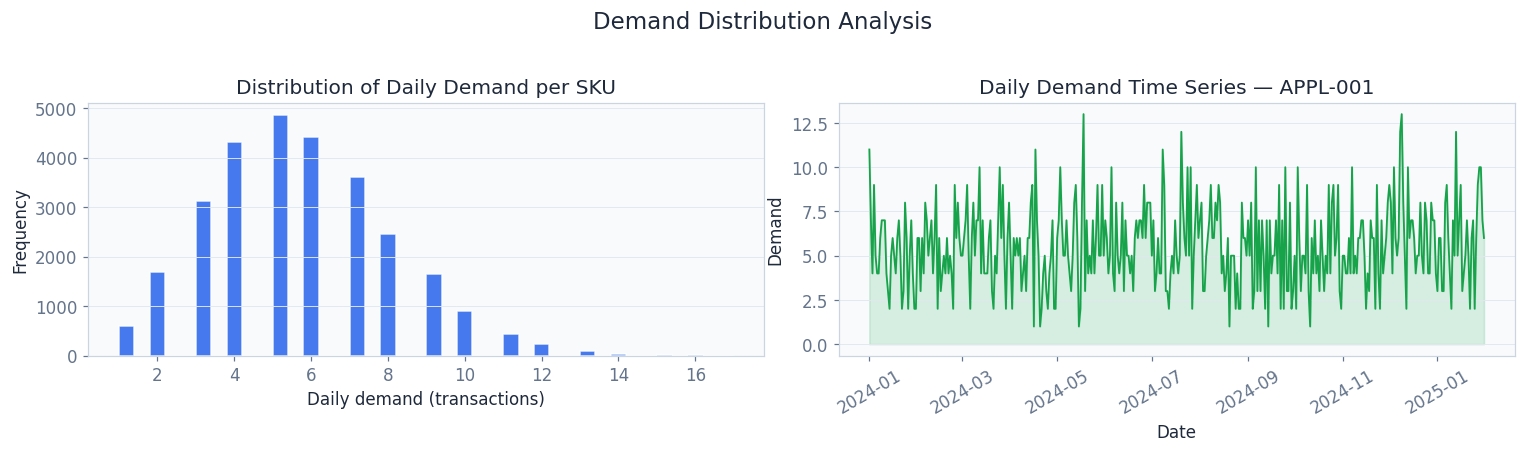


Descriptive statistics for daily demand:
count    28466.00
mean         5.62
std          2.36
min          1.00
25%          4.00
50%          5.00
75%          7.00
max         17.00
Name: demand, dtype: float64


In [9]:
# Demand distribution across all SKUs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of daily demand values
axes[0].hist(daily["demand"], bins=40, color=ACCENT, edgecolor=BG, alpha=0.85)
axes[0].set_title("Distribution of Daily Demand per SKU")
axes[0].set_xlabel("Daily demand (transactions)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, axis="y")

# Line chart for a sample SKU
sample_sku = daily["SKU"].iloc[0]
sku_ts = daily[daily["SKU"] == sample_sku].sort_values("Date")
axes[1].plot(sku_ts["Date"], sku_ts["demand"], color=GREEN, lw=1.2)
axes[1].fill_between(sku_ts["Date"], sku_ts["demand"], alpha=0.15, color=GREEN)
axes[1].set_title(f"Daily Demand Time Series — {sample_sku}")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Demand")
axes[1].grid(True, axis="y")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Demand Distribution Analysis", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "demand_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nDescriptive statistics for daily demand:")
print(daily["demand"].describe().round(2))